In [49]:
# ── dependencies ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import seaborn as sns

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

plt.style.use('dark_background')
sns.set_palette('husl')
print('imports ok')

imports ok


In [ ]:
sector_symbol = [
    # {'id': 500, 'level': 2, 'name': 'Dầu khí'},
    # {'id': 1300, 'level': 2, 'name': 'Hóa chất'},
    # {'id': 1700, 'level': 2, 'name': 'Tài nguyên Cơ bản'},
    # {'id': 2300, 'level': 2, 'name': 'Xây dựng và Vật liệu'},
    # {'id': 2700, 'level': 2, 'name': 'Hàng & Dịch vụ Công nghiệp'},
    # # {'id': 3300, 'level': 2, 'name': 'Ô tô và phụ tùng'},
    # # {'id': 3500, 'level': 2, 'name': 'Thực phẩm và đồ uống'},
    # # {'id': 3700, 'level': 2, 'name': 'Hàng cá nhân & Gia dụng'},
    # # {'id': 4500, 'level': 2, 'name': 'Y tế'},
    # {'id': 5300, 'level': 2, 'name': 'Bán lẻ'},
    # # {'id': 5500, 'level': 2, 'name': 'Truyền thông'},
    # # {'id': 5700, 'level': 2, 'name': 'Du lịch và Giải trí'},
    # # {'id': 6500, 'level': 2, 'name': 'Viễn thông'},
    # # {'id': 7500, 'level': 2, 'name': 'Điện, nước & xăng dầu khí đốt'},
    # {'id': 8300, 'level': 2, 'name': 'Ngân hàng'},
    # {'id': 8500, 'level': 2, 'name': 'Bảo hiểm'},
    # {'id': 8600, 'level': 2, 'name': 'Bất động sản'},
    # {'id': 8700, 'level': 2, 'name': 'Dịch vụ tài chính'},
    # # {'id': 8900, 'level': 2, 'name': 'Đầu tư chứng khoán/phi chứng khoán'},
    # {'id': 9500, 'level': 2, 'name': 'Công nghệ Thông tin'},

    {'id': 8000, 'level': 1, 'name': 'Tài chính'},
    {'id': 1, 'level': 1, 'name': 'Dầu khí'},
    {'id': 3000, 'level': 1, 'name': 'Hang tieu dung'},
    {'id': 1000, 'level': 1, 'name': 'Nguyen vat lieu'},
    {'id': 2000, 'level': 1, 'name': 'Cong nghiep'},
    {'id': 5000, 'level': 1, 'name': 'Dich vu'},
    {'id': 9000, 'level': 1, 'name': 'CNTT'},
    {'id': 7000, 'level': 1, 'name': 'Tien ich'},
]

# sector_id 500 → ClickHouse symbol '0500' (4-digit padding, same as stock_service sectors)
def sector_id_to_symbol(sector_id: int) -> str:
    return f"{sector_id:04d}"

SECTOR_SYMBOLS = [sector_id_to_symbol(s['id']) for s in sector_symbol]
SECTOR_ID_BY_SYMBOL = {sector_id_to_symbol(s['id']): s['id'] for s in sector_symbol}
SECTOR_NAME_BY_SYMBOL = {sector_id_to_symbol(s['id']): s['name'] for s in sector_symbol}

BENCHMARK_SYMBOL = 'VNINDEX'
LOAD_SYMBOLS = SECTOR_SYMBOLS + [BENCHMARK_SYMBOL]
SECTOR_NAME_BY_SYMBOL[BENCHMARK_SYMBOL] = BENCHMARK_SYMBOL

print(f"{len(SECTOR_SYMBOLS)} sector symbols:", SECTOR_SYMBOLS[:5], '...')
print(f"benchmark: {BENCHMARK_SYMBOL}")


8 sector symbols: ['8000', '0001', '3000', '1000', '2000'] ...
benchmark: VNINDEX


In [51]:
# ── Load sector OHLC from ClickHouse (mirrors stock_service._load_delta_stocks) ──
import os

import clickhouse_connect
import pandas as pd

DEFAULT_STOCK_COLUMNS = ['date', 'open', 'high', 'low', 'close', 'volume', 'symbol']


def load_sector_ohlc(
    symbols: list[str],
    columns: list[str] | None = None,
) -> pd.DataFrame:
    query_columns = columns or DEFAULT_STOCK_COLUMNS
    selected_cols = list(dict.fromkeys([*query_columns, 'date', 'symbol']))

    def _sql_quote(s: str) -> str:
        return "'" + s.replace("'", "''") + "'"

    symbol_list = ', '.join(_sql_quote(s) for s in symbols)
    table_name = os.getenv('CLICKHOUSE_OHLC_EOD_TABLE', 'ohlc_eod')
    db = os.getenv('CLICKHOUSE_DB', 'default')

    sql = f"""
        SELECT {', '.join(selected_cols)}
        FROM {db}.{table_name} FINAL
        WHERE symbol IN ({symbol_list})
        ORDER BY symbol, date
    """
    print('[PERF] clickhouse query:', ' '.join(sql.split()))

    client = clickhouse_connect.get_client(
        host=os.getenv('CLICKHOUSE_HOST', 'localhost'),
        port=int(os.getenv('CLICKHOUSE_PORT', '9010')),
        username=os.getenv('CLICKHOUSE_USER', 'myuser'),
        password=os.getenv('CLICKHOUSE_PASSWORD', 'mypassword'),
        database=db,
    )
    try:
        result = client.query(sql)
        pdf = pd.DataFrame(result.result_rows, columns=result.column_names)
    finally:
        client.close()

    if pdf.empty:
        return pdf

    pdf['date'] = pd.to_datetime(pdf['date'])
    pdf = pdf.drop_duplicates(subset=['symbol', 'date'], keep='last')
    pdf = pdf.sort_values(['symbol', 'date']).reset_index(drop=True)
    if columns:
        pdf = pdf[[c for c in columns if c in pdf.columns]]
    return pdf


sector_ohlc = load_sector_ohlc(
    symbols=LOAD_SYMBOLS,
    columns=DEFAULT_STOCK_COLUMNS,
)

print(f"Loaded {len(sector_ohlc):,} rows | {sector_ohlc['symbol'].nunique()} symbols")
if not sector_ohlc.empty:
    print(f"Date range: {sector_ohlc['date'].min().date()} → {sector_ohlc['date'].max().date()}")

missing = sorted(set(SECTOR_SYMBOLS) - set(sector_ohlc['symbol'].unique()))
if missing:
    print('No sector data:', [f"{s} ({SECTOR_NAME_BY_SYMBOL[s]})" for s in missing])
if BENCHMARK_SYMBOL not in sector_ohlc['symbol'].values:
    print(f'Warning: {BENCHMARK_SYMBOL} not found in ClickHouse')

# ── wide OHLCV panel (same layout as backtest_005d stocks / df_raw) ───────────
OHLCV_FIELDS = ['open', 'high', 'low', 'close', 'volume']

raw = (
    sector_ohlc
    .set_index(['date', 'symbol'])[OHLCV_FIELDS]
    .sort_index()
)
stocks = raw.unstack(level='symbol').bfill().ffill()

open_   = stocks['open']
high    = stocks['high']
low     = stocks['low']
close   = stocks['close']
volume  = stocks['volume']

print(f'Shape: {close.shape}  |  {close.index[0]} → {close.index[-1]}')
close.head(3)

[PERF] clickhouse query: SELECT date, open, high, low, close, volume, symbol FROM default.ohlc_eod FINAL WHERE symbol IN ('8000', '0001', '3000', '1000', '2000', '5000', '9000', '70000', 'VNINDEX') ORDER BY symbol, date
Loaded 16,118 rows | 8 symbols
Date range: 2000-07-28 → 2026-06-18
No sector data: ['70000 (Tien ich)']
Shape: (6297, 8)  |  2000-07-28 00:00:00 → 2026-06-18 00:00:00


symbol,0001,1000,2000,3000,5000,8000,9000,VNINDEX
date,,,,,,,,
2000-07-28,82.880905,107.961449,90.265251,91.558662,72.093277,90.568771,102.923485,100.000000
2000-07-31,82.880905,107.961449,90.265251,91.558662,72.093277,90.568771,102.923485,101.550003
2000-08-02,82.880905,107.961449,90.265251,91.558662,72.093277,90.568771,102.923485,103.379997


## Geometric Regime Detection — Wedge Product Volume (GA-WPD)

Treat the 20 VN sector indices as vectors in space. The **wedge product**
$\|v_1 \wedge \cdots \wedge v_n\| = \sqrt{\det(G)}$ (G = Gram matrix of *direction-normalized*
returns) measures the **oriented volume** the sectors span over a rolling window.

- **Volume high** → sectors point in different directions (rotation, healthy diversification).
- **Volume → 0** → vectors collapse onto a line (everything sells off together = crisis / dimensionality collapse).

Unlike an HMM (which fits the *distribution* of returns and flickers on outliers), the wedge volume
measures the *structure* of the cross-section, so it is continuous and far more stable.

Adapted from the SPDR-sector study to the **VN market**: 20 sector indices as the basis, **VNINDEX** as
the price context. Returns are recomputed from *unfilled* prices (the loader's `bfill/ffill` would inject
fake zero-returns that corrupt the Gram matrix) and the analysis starts at the first date where all
sectors are live.

In [52]:
# ── Clean sector returns (no fake fills) + common live window ─────────────────
# `raw` (long, unfilled) -> NaN-preserving wide. Avoids the bfill/ffill zero-returns
# that would collapse the Gram matrix.
close_raw = raw['close'].unstack('symbol')

sector_close = close_raw[SECTOR_SYMBOLS]
bench_close  = close_raw[BENCHMARK_SYMBOL].ffill()   # VNINDEX for price context only

# Start where every sector has real data (all 20 live).
all_live = sector_close.notna().all(axis=1)
start_date = all_live.idxmax()
sector_close = sector_close.loc[start_date:]

# Drop any residual gaps, then log returns.
sector_close = sector_close.dropna(how='any')
sector_returns = np.log(sector_close / sector_close.shift(1)).dropna()

bench_price = bench_close.reindex(sector_returns.index).ffill()

print(f"All 20 sectors live from: {start_date.date()}")
print(f"Return matrix: {sector_returns.shape[0]:,} days x {sector_returns.shape[1]} sectors")
print(f"Window: {sector_returns.index[0].date()} -> {sector_returns.index[-1].date()}")
sector_returns.tail(3)

KeyError: "['70000'] not in index"

In [ ]:
# ── Wedge Product Volume ──────────────────────────────────────────────────────
# Volume = ||v1 ^ ... ^ vn|| = sqrt(det(G)),  G = Gram matrix of direction-
# normalized return vectors. Direction-only normalization isolates correlation
# *structure* from volatility magnitude.
#
# n=20 sectors -> det(G) underflows on a linear scale, so we work in log space via
# slogdet and also return a per-dimension volume vol^(1/n) in (0, 1] for an
# interpretable, scale-stable signal (1 = orthogonal/diversified, 0 = collapsed).

WEDGE_WINDOW = 60   # ~3 trading months


def wedge_volume(returns: pd.DataFrame, window: int = WEDGE_WINDOW) -> pd.DataFrame:
    X = returns.values
    n = X.shape[1]
    dates = returns.index[window:]

    log_vols = []
    for i in range(window, len(X)):
        w = X[i - window:i]                       # (window, n)

        # 1. direction-normalize each asset column (angle, not magnitude)
        norms = np.linalg.norm(w, axis=0)
        norms[norms == 0] = 1e-12
        wn = w / norms

        # 2. Gram matrix of cosine similarities
        gram = wn.T @ wn

        # 3. log-volume via slogdet (numerically stable for n=20)
        sign, logdet = np.linalg.slogdet(gram)
        log_vols.append(logdet if sign > 0 else -np.inf)

    log_vols = np.asarray(log_vols)
    return pd.DataFrame(
        {
            "log_volume":  0.5 * log_vols,                  # log of raw wedge volume
            "volume":      np.exp(0.5 * log_vols),          # raw volume (tiny for n=20)
            "volume_per_dim": np.exp(0.5 * log_vols / n),   # geo-mean per dimension, (0,1]
        },
        index=dates,
    )


wedge = wedge_volume(sector_returns, window=WEDGE_WINDOW)

# Collapse threshold = 15th percentile of the per-dimension volume.
WEDGE_THRESHOLD = wedge["volume_per_dim"].quantile(0.15)
wedge["crisis"] = wedge["volume_per_dim"] < WEDGE_THRESHOLD

print(f"Wedge volume computed: {len(wedge):,} days (window={WEDGE_WINDOW})")
print(f"volume_per_dim  range: {wedge['volume_per_dim'].min():.3f} -> {wedge['volume_per_dim'].max():.3f}")
print(f"collapse threshold (15th pct): {WEDGE_THRESHOLD:.3f}")
print(f"latest ({wedge.index[-1].date()}): "
      f"vol/dim={wedge['volume_per_dim'].iloc[-1]:.3f}  "
      f"{'⚠️ COLLAPSE' if wedge['crisis'].iloc[-1] else 'OK'}")
wedge.tail(3)

Wedge volume computed: 1,334 days (window=60)
volume_per_dim  range: 0.509 -> 0.884
collapse threshold (15th pct): 0.559
latest (2026-05-29): vol/dim=0.797  OK


,log_volume,volume,volume_per_dim,crisis
date,,,,
2026-05-21,-2.259715,0.104380,0.797741,False
2026-05-26,-2.260503,0.104298,0.797678,False
2026-05-29,-2.267560,0.103565,0.797115,False


In [ ]:
# ── Baseline: Gaussian HMM (the flickering benchmark) ─────────────────────────
def fit_hmm(returns: pd.DataFrame):
    X = returns.values
    model = GaussianHMM(n_components=2, covariance_type="full",
                        n_iter=200, random_state=42)
    model.fit(X)
    states = model.predict(X)
    probs  = model.predict_proba(X)

    # Label the higher-average-variance state as "crisis".
    vol0 = np.mean(np.diag(model.covars_[0]))
    vol1 = np.mean(np.diag(model.covars_[1]))
    crisis = 1 if vol0 < vol1 else 0

    crisis_state = pd.Series((states == crisis).astype(int), index=returns.index)
    crisis_prob  = pd.Series(probs[:, crisis], index=returns.index)
    return crisis_state, crisis_prob


hmm_state, hmm_prob = fit_hmm(sector_returns)

# How often each method flags crisis + how often it flips (flicker proxy).
hmm_flips   = int((hmm_state.diff().abs() == 1).sum())
wedge_flips = int((wedge["crisis"].astype(int).diff().abs() == 1).sum())
print(f"HMM   crisis days: {hmm_state.mean():6.1%}   regime flips: {hmm_flips}")
print(f"Wedge crisis days: {wedge['crisis'].mean():6.1%}   regime flips: {wedge_flips}")
print(f"Wedge is {hmm_flips / max(wedge_flips,1):.1f}x more stable (fewer flips)")

HMM   crisis days:  27.0%   regime flips: 201
Wedge crisis days:  15.0%   regime flips: 24
Wedge is 8.4x more stable (fewer flips)


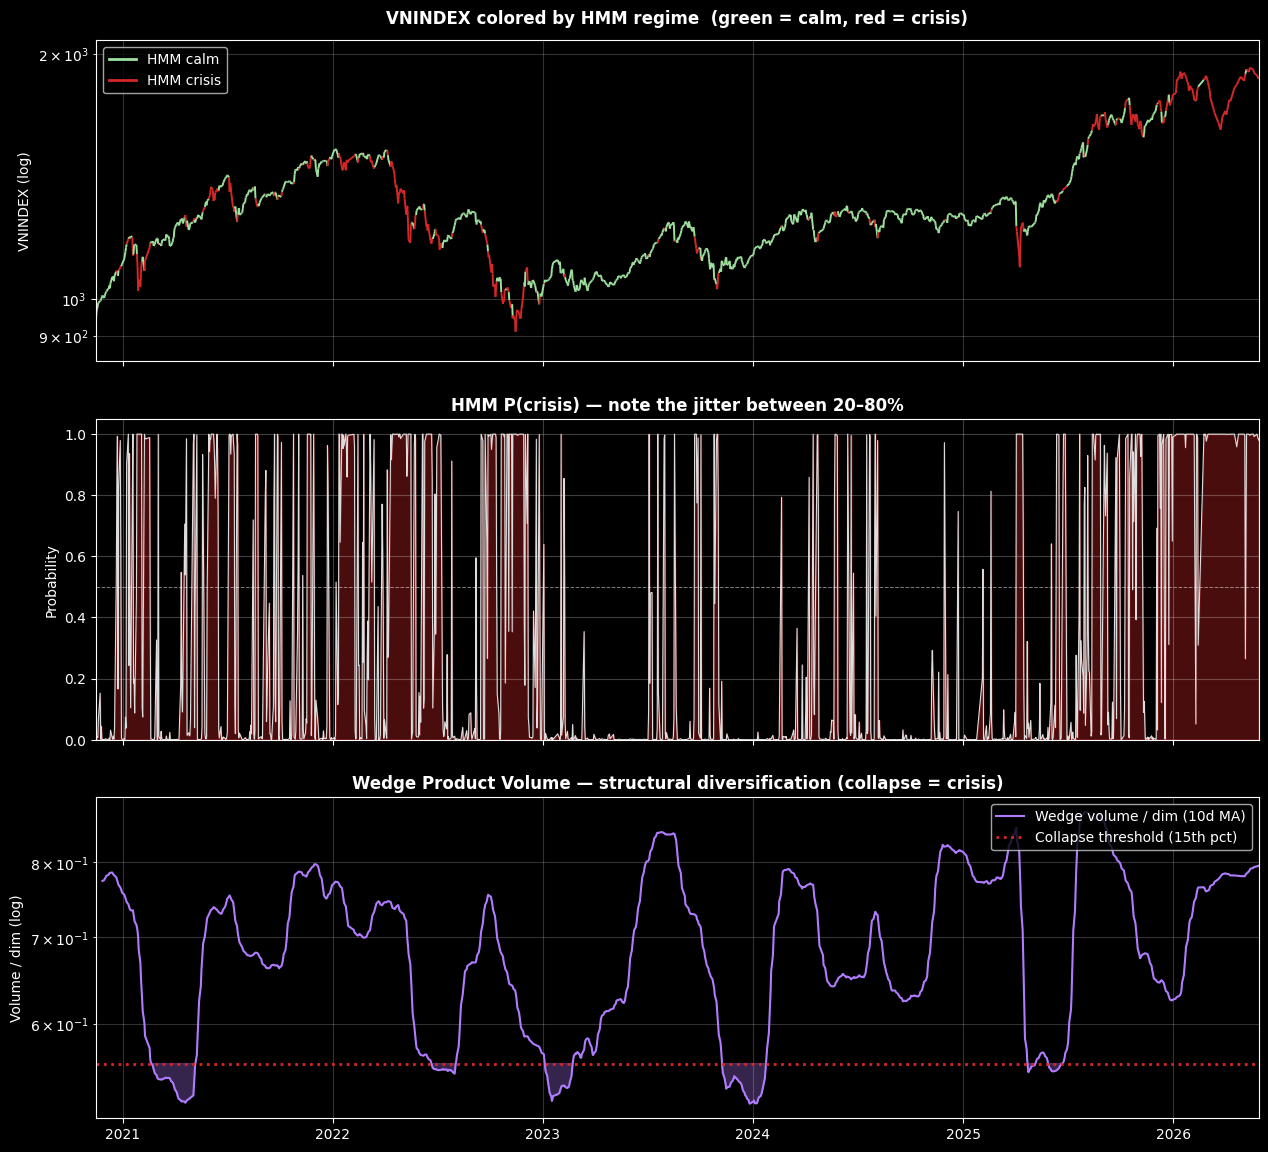

In [ ]:
# ── Regime Dashboard: VNINDEX vs HMM vs Wedge Volume ──────────────────────────
from matplotlib.collections import LineCollection
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D

# Align everything to the wedge window (HMM covers more, wedge is the shortest).
idx = wedge.index
px      = bench_price.loc[idx]
state   = hmm_state.loc[idx]
prob    = hmm_prob.loc[idx]
vpd     = wedge["volume_per_dim"].loc[idx].rolling(10).mean()

fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
plt.subplots_adjust(hspace=0.18)

# Panel 1 — VNINDEX colored by HMM regime
x = mdates.date2num(px.index.to_pydatetime())
pts = np.array([x, px.values]).T.reshape(-1, 1, 2)
segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
cmap = ListedColormap(["#9ee09e", "#d62728"])
lc = LineCollection(segs, cmap=cmap, norm=BoundaryNorm([0, 0.5, 1], cmap.N))
lc.set_array(state.values[:-1]); lc.set_linewidth(1.4)
axes[0].add_collection(lc)
axes[0].set_xlim(px.index.min(), px.index.max())
axes[0].set_ylim(px.min() * 0.92, px.max() * 1.08)
axes[0].set_yscale("log")
axes[0].set_title("VNINDEX colored by HMM regime  (green = calm, red = crisis)",
                  fontsize=12, fontweight="bold", pad=12)
axes[0].set_ylabel("VNINDEX (log)")
axes[0].grid(True, which="both", alpha=0.2)
axes[0].legend([Line2D([0], [0], color="#9ee09e", lw=2),
                Line2D([0], [0], color="#d62728", lw=2)],
               ["HMM calm", "HMM crisis"], loc="upper left")

# Panel 2 — HMM crisis probability (the "flickering" / uncertainty)
axes[1].plot(prob.index, prob, color="#dddddd", lw=0.8)
axes[1].fill_between(prob.index, 0, prob, color="#d62728", alpha=0.35)
axes[1].axhline(0.5, color="white", ls="--", lw=0.7, alpha=0.5)
axes[1].set_title("HMM P(crisis) — note the jitter between 20–80%",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Probability"); axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.25)

# Panel 3 — Wedge volume (structural diversification)
axes[2].semilogy(vpd.index, vpd, color="#b07cff", lw=1.5, label="Wedge volume / dim (10d MA)")
axes[2].axhline(WEDGE_THRESHOLD, color="#d62728", ls=":", lw=2,
                label="Collapse threshold (15th pct)")
axes[2].fill_between(vpd.index, vpd, WEDGE_THRESHOLD,
                     where=(vpd < WEDGE_THRESHOLD), color="#b07cff", alpha=0.3)
axes[2].set_title("Wedge Product Volume — structural diversification (collapse = crisis)",
                  fontsize=12, fontweight="bold")
axes[2].set_ylabel("Volume / dim (log)")
axes[2].grid(True, which="both", alpha=0.2)
axes[2].legend(loc="upper right")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.show()

12 collapse band(s):
  2021-02-08 -> 2021-02-08  (0d)
  2021-02-17 -> 2021-05-04  (76d)
  2022-06-14 -> 2022-07-21  (37d)
  2022-07-25 -> 2022-08-01  (7d)
  2023-01-04 -> 2023-02-16  (43d)
  2023-02-28 -> 2023-03-01  (1d)
  2023-03-23 -> 2023-03-23  (0d)
  2023-11-01 -> 2023-11-01  (0d)
  2023-11-03 -> 2024-01-19  (77d)
  2025-04-11 -> 2025-04-22  (11d)
  2025-04-24 -> 2025-04-24  (0d)
  2025-05-21 -> 2025-06-13  (23d)


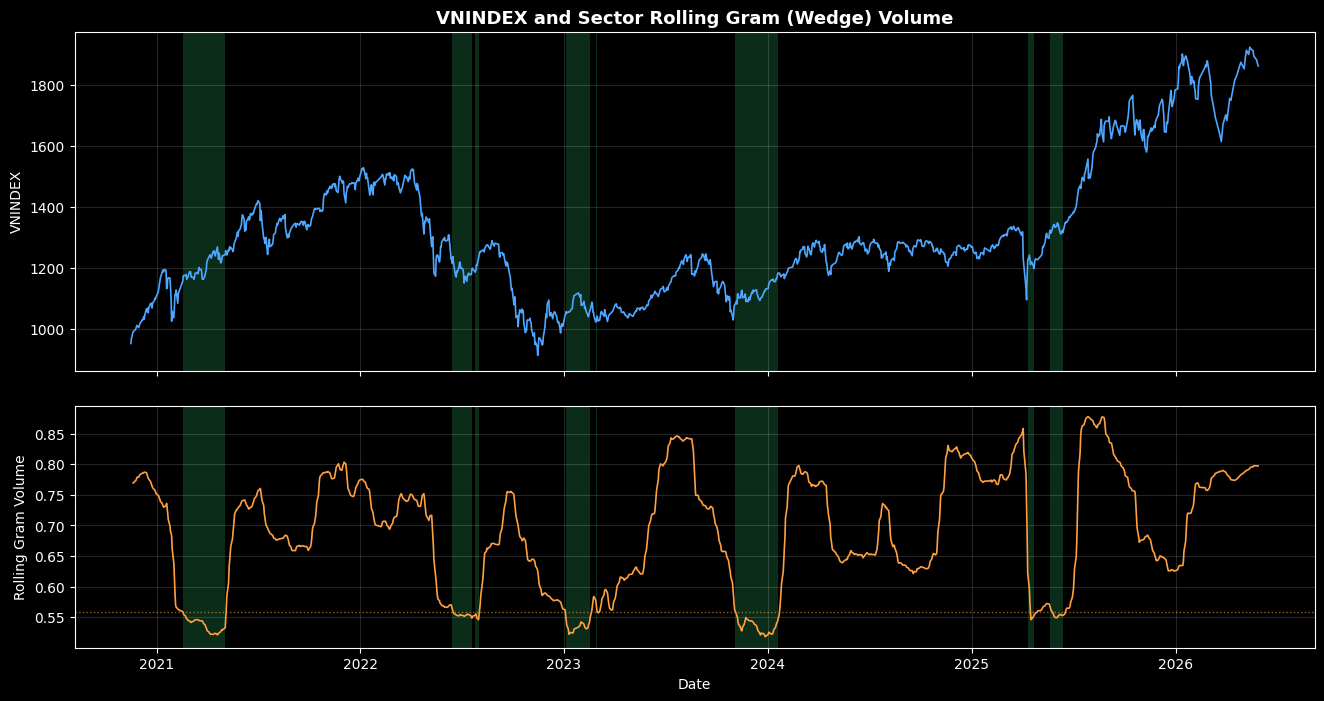

In [ ]:
# ── VNINDEX + Rolling Gram (Wedge) Volume, with collapse bands ────────────────
def crisis_spans(mask: pd.Series):
    """Yield (start, end) date pairs for each contiguous True run."""
    m = mask.values.astype(int)
    idx = mask.index
    edges = np.diff(np.concatenate([[0], m, [0]]))
    starts = np.where(edges == 1)[0]
    ends   = np.where(edges == -1)[0] - 1
    return [(idx[s], idx[e]) for s, e in zip(starts, ends)]


idx   = wedge.index
px    = bench_price.loc[idx]
vol   = wedge["volume_per_dim"].loc[idx].rolling(5).mean()
spans = crisis_spans(wedge["crisis"].loc[idx])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1.4, 1]})
fig.subplots_adjust(hspace=0.12)

# Top — VNINDEX
axes[0].plot(px.index, px.values, color="#4da6ff", lw=1.2)
axes[0].set_title("VNINDEX and Sector Rolling Gram (Wedge) Volume",
                  fontsize=13, fontweight="bold")
axes[0].set_ylabel("VNINDEX")
axes[0].grid(True, alpha=0.15)

# Bottom — rolling wedge volume
axes[1].plot(vol.index, vol.values, color="#ff9f40", lw=1.2)
axes[1].axhline(WEDGE_THRESHOLD, color="#ff9f40", ls=":", lw=1, alpha=0.6)
axes[1].set_ylabel("Rolling Gram Volume")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.15)

# Shared green collapse bands on both panels
for ax in axes:
    for s, e in spans:
        ax.axvspan(s, e, color="#2ecc71", alpha=0.22, lw=0)

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

print(f"{len(spans)} collapse band(s):")
for s, e in spans:
    print(f"  {s.date()} -> {e.date()}  ({(e - s).days}d)")
plt.show()

In [ ]:
close_raw = raw['close'].unstack('symbol')

sector_close = close_raw[SECTOR_SYMBOLS]
bench_close  = close_raw[BENCHMARK_SYMBOL].ffill()

all_live = sector_close.notna().all(axis=1)
start_date = all_live.idxmax()
sector_close = sector_close.loc[start_date:]
sector_close = sector_close.dropna(how='any')
sector_returns = np.log(sector_close / sector_close.shift(1)).dropna()
bench_price = bench_close.reindex(sector_returns.index).ffill()

print(f"All 20 sectors live from: {start_date.date()}")
print(f"Return matrix: {sector_returns.shape[0]:,} days x {sector_returns.shape[1]} sectors")
print(f"Window: {sector_returns.index[0].date()} -> {sector_returns.index[-1].date()}")

All 20 sectors live from: 2020-08-20
Return matrix: 1,394 days x 10 sectors
Window: 2020-08-21 -> 2026-05-29


In [ ]:
WEDGE_WINDOW = 60

def wedge_volume(returns, window=WEDGE_WINDOW):
    X = returns.values
    n = X.shape[1]
    dates = returns.index[window:]
    log_vols = []
    for i in range(window, len(X)):
        w = X[i - window:i]
        norms = np.linalg.norm(w, axis=0)
        norms[norms == 0] = 1e-12
        wn = w / norms
        gram = wn.T @ wn
        sign, logdet = np.linalg.slogdet(gram)
        log_vols.append(logdet if sign > 0 else -np.inf)
    log_vols = np.asarray(log_vols)
    return pd.DataFrame({
        "log_volume": 0.5 * log_vols,
        "volume": np.exp(0.5 * log_vols),
        "volume_per_dim": np.exp(0.5 * log_vols / n),
    }, index=dates)

wedge = wedge_volume(sector_returns, window=WEDGE_WINDOW)
WEDGE_THRESHOLD = wedge["volume_per_dim"].quantile(0.15)
wedge["crisis"] = wedge["volume_per_dim"] < WEDGE_THRESHOLD
print(f"Wedge volume computed: {len(wedge):,} days (window={WEDGE_WINDOW})")
print(f"volume_per_dim range: {wedge['volume_per_dim'].min():.3f} -> {wedge['volume_per_dim'].max():.3f}")
print(f"collapse threshold (15th pct): {WEDGE_THRESHOLD:.3f}")
print(f"latest ({wedge.index[-1].date()}): vol/dim={wedge['volume_per_dim'].iloc[-1]:.3f} "
      f"{'COLLAPSE' if wedge['crisis'].iloc[-1] else 'OK'}")
# sanity: worst collapse dates
print("\nDeepest collapse days:")
print(wedge.nsmallest(5, "volume_per_dim")[["volume_per_dim"]])

Wedge volume computed: 1,334 days (window=60)
volume_per_dim range: 0.509 -> 0.884
collapse threshold (15th pct): 0.559
latest (2026-05-29): vol/dim=0.797 OK

Deepest collapse days:
            volume_per_dim
date                      
2023-12-26        0.508828
2021-04-20        0.513773
2023-12-25        0.514365
2023-12-18        0.515738
2023-12-19        0.516572


In [ ]:
def wedge_volume(returns, window=WEDGE_WINDOW):
    X = returns.values
    n = X.shape[1]
    dates = returns.index[window:]
    log_vols = []
    for i in range(window, len(X)):
        w = X[i - window:i]
        norms = np.linalg.norm(w, axis=0)
        norms[norms == 0] = 1e-12
        wn = w / norms
        gram = wn.T @ wn
        # robust log-det via clipped eigenvalues (Gram is symmetric PSD;
        # roundoff can push tiny eigenvalues slightly negative)
        eig = np.linalg.eigvalsh(gram)
        eig = np.clip(eig, 1e-12, None)
        log_vols.append(np.sum(np.log(eig)))
    log_vols = np.asarray(log_vols)
    return pd.DataFrame({
        "log_volume": 0.5 * log_vols,
        "volume": np.exp(0.5 * log_vols),
        "volume_per_dim": np.exp(0.5 * log_vols / n),
    }, index=dates)

wedge = wedge_volume(sector_returns, window=WEDGE_WINDOW)
WEDGE_THRESHOLD = wedge["volume_per_dim"].quantile(0.15)
wedge["crisis"] = wedge["volume_per_dim"] < WEDGE_THRESHOLD
print(f"volume_per_dim range: {wedge['volume_per_dim'].min():.4f} -> {wedge['volume_per_dim'].max():.4f}")
print(f"collapse threshold (15th pct): {WEDGE_THRESHOLD:.4f}")
print(f"latest ({wedge.index[-1].date()}): vol/dim={wedge['volume_per_dim'].iloc[-1]:.4f} "
      f"{'COLLAPSE' if wedge['crisis'].iloc[-1] else 'OK'}\n")
print("Deepest collapse days (should line up with VN sell-offs):")
print(wedge.nsmallest(8, "volume_per_dim")[["volume_per_dim"]])

volume_per_dim range: 0.5088 -> 0.8845
collapse threshold (15th pct): 0.5592
latest (2026-05-29): vol/dim=0.7971 OK

Deepest collapse days (should line up with VN sell-offs):
            volume_per_dim
date                      
2023-12-26        0.508828
2021-04-20        0.513773
2023-12-25        0.514365
2023-12-18        0.515738
2023-12-19        0.516572
2024-01-08        0.517828
2023-01-05        0.517901
2021-04-19        0.518202


In [ ]:
from hmmlearn.hmm import GaussianHMM

def fit_hmm(returns):
    X = returns.values
    model = GaussianHMM(n_components=2, covariance_type="full", n_iter=200, random_state=42)
    model.fit(X)
    states = model.predict(X)
    probs = model.predict_proba(X)
    vol0 = np.mean(np.diag(model.covars_[0])); vol1 = np.mean(np.diag(model.covars_[1]))
    crisis = 1 if vol0 < vol1 else 0
    return (pd.Series((states == crisis).astype(int), index=returns.index),
            pd.Series(probs[:, crisis], index=returns.index))

hmm_state, hmm_prob = fit_hmm(sector_returns)
hmm_flips = int((hmm_state.diff().abs() == 1).sum())
wedge_flips = int((wedge["crisis"].astype(int).diff().abs() == 1).sum())
print(f"HMM   crisis days: {hmm_state.mean():6.1%}   regime flips: {hmm_flips}")
print(f"Wedge crisis days: {wedge['crisis'].mean():6.1%}   regime flips: {wedge_flips}")
print(f"Wedge is {hmm_flips / max(wedge_flips,1):.1f}x more stable (fewer flips)")

HMM   crisis days:  27.0%   regime flips: 201
Wedge crisis days:  15.0%   regime flips: 24
Wedge is 8.4x more stable (fewer flips)
